<a href="https://www.kaggle.com/code/shreyanshgangwar1509/aircraft?scriptVersionId=221362797" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Python Libraries and Their Uses

### 1. **Matplotlib**
- **`import matplotlib.pyplot as plt`**  
  Used for plotting and visualizing data. It provides functions to create static, animated, and interactive plots.

### 2. **NumPy**
- **`import numpy as np`**  
  Provides support for large multi-dimensional arrays and matrices, along with a collection of mathematical functions to operate on these arrays.

### 3. **OpenCV**
- **`import cv2`**  
  A computer vision library used for image and video processing tasks, such as reading, transforming, and analyzing images.

### 4. **Pillow (PIL)**
- **`import PIL`**  
  A Python Imaging Library used for opening, manipulating, and saving many different image file formats.

### 5. **Random**
- **`import random`**  
  Used to generate random numbers, shuffle data, and perform random sampling.

### 6. **TensorFlow**
- **`import tensorflow as tf`**  
  An open-source library for machine learning and deep learning. It is used for building and training neural networks.

### 7. **Seaborn**
- **`import seaborn as sns`**  
  A visualization library built on top of Matplotlib, providing a high-level interface for creating attractive and informative statistical graphics.

### 8. **Pathlib**
- **`import pathlib`**  
  Provides an object-oriented interface for working with file system paths.

### 9. **OS**
- **`import os`**  
  Provides functions to interact with the operating system, such as file handling, directory management, and environment variables.

### 10. **Pandas**
- **`import pandas as pd`**  
  A powerful data manipulation and analysis library. It offers data structures like DataFrames to handle structured data easily.

### 11. **Scikit-learn**
- **`from sklearn.model_selection import train_test_split`**  
  Provides simple and efficient tools for data mining and machine learning, including functions for splitting datasets into training and testing sets.

### 12. **Keras (via TensorFlow)**
- **`from tensorflow import keras`**  
  A high-level API for building and training deep learning models, included as part of TensorFlow.

- **`from tensorflow.keras import backend as K`**  
  Provides backend operations for TensorFlow, allowing low-level manipulation of tensors and models.

- **`from tensorflow.keras import layers`**  
  Offers a wide variety of layers to build neural networks, like convolutional layers, pooling layers, and dense layers.

- **`from tensorflow.keras.models import Sequential`**  
  A simple way to build neural networks by stacking layers sequentially.

- **`from tensorflow.keras.preprocessing.image import ImageDataGenerator`**  
  A tool for real-time data augmentation, which helps improve model generalization by applying transformations like rotation, scaling, and flipping to images.

- **`from tensorflow.keras.utils import to_categorical`**  
  Converts class vectors (integers) to binary class matrices (one-hot encoding), often used in classification tasks.

### 13. **Scikit-learn Metrics**
- **`from sklearn.metrics import confusion_matrix, classification_report`**  
  Provides tools to evaluate model performance. `confusion_matrix` visualizes the performance of a classification model, while `classification_report` provides detailed metrics like precision, recall, and F1-score.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import PIL
import random
import tensorflow as tf
import seaborn as sns
import pathlib
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import backend  as K
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix,classification_report

# Loading and Organizing Aircraft Image Dataset

### 1. **Setting the Dataset Directory**
- **`data_dir = pathlib.Path('/kaggle/input/militaryaircraftdetectiondataset/crop')`**  
  Specifies the path to the dataset directory using `pathlib`. This directory contains folders for different aircraft classes.

### 2. **Listing All Items in the Dataset Directory**
- **`data = list(data_dir.glob('*'))`**  
  Retrieves all items (files and folders) in the dataset directory.

### 3. **Extracting Folder Names (Aircraft Classes)**
- **`folders = [folder.name for folder in data_dir.glob('*') if folder.is_dir()]`**  
  Extracts the names of folders, which represent different aircraft classes.

### 4. **Mapping Aircraft Classes to Numerical Labels**
- **`aircraft_label_dict = {folder: idx for idx, folder in enumerate(folders)}`**  
  Creates a dictionary mapping each aircraft class (folder name) to a unique numerical label (index).  
  Example:  
  ```python
  {'F16': 0, 'B2Bomber': 1, 'Apache': 2, ...}


In [2]:


data_dir = pathlib.Path('/kaggle/input/militaryaircraftdetectiondataset/crop')

data = list(data_dir.glob('*')) 

folders = [folder.name for folder in data_dir.glob('*') if folder.is_dir()]


aircraft_label_dict = {folder: idx for idx, folder in enumerate(folders)}


aircraft_image_dict = {folder.name: list(folder.glob('*')) for folder in data_dir.glob('*') if folder.is_dir()}
# aircraft_label_dict
len(aircraft_image_dict.items())


77

# Counting Classes and Images in the Aircraft Dataset

### 1. **Listing All Classes (Folders)**
- **`classes = sorted(os.listdir(data_dir))`**  
  Lists all folders (representing aircraft classes) in the dataset directory and sorts them alphabetically.

- **`print(f"Total classes: {len(classes)}")`**  
  Prints the total number of aircraft classes.

---

### 2. **Counting Images Per Class**
- **`class_counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) for cls in classes}`**  
  For each class (folder), counts the number of images by listing the files inside the folder.  
  Example Output:  
  ```python
  {'F16': 120, 'B2Bomber': 150, 'Apache': 95, ...}


In [6]:



classes = sorted(os.listdir(data_dir))  
print(f"Total classes: {len(classes)}")  

# Count images per class
class_counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) for cls in classes}
total_images = sum(class_counts.values())

print(f"Total images: {total_images}")
print(f"Images per class : {dict(list(class_counts.items())[:])}")


Total classes: 77
Total images: 33544
Images per class : {'A10': 698, 'A400M': 469, 'AG600': 263, 'AH64': 411, 'AV8B': 439, 'An124': 184, 'An22': 94, 'An225': 94, 'An72': 176, 'B1': 630, 'B2': 515, 'B21': 46, 'B52': 581, 'Be200': 296, 'C130': 1413, 'C17': 678, 'C2': 813, 'C390': 147, 'C5': 389, 'CH47': 279, 'CL415': 336, 'E2': 452, 'E7': 210, 'EF2000': 779, 'F117': 366, 'F14': 522, 'F15': 1459, 'F16': 1749, 'F18': 1594, 'F22': 670, 'F35': 1367, 'F4': 679, 'H6': 412, 'J10': 676, 'J20': 756, 'J35': 32, 'JAS39': 571, 'JF17': 214, 'JH7': 271, 'KAAN': 49, 'KC135': 384, 'KF21': 114, 'KJ600': 52, 'Ka27': 107, 'Ka52': 199, 'MQ9': 359, 'Mi24': 280, 'Mi26': 80, 'Mi28': 146, 'Mi8': 213, 'Mig29': 292, 'Mig31': 467, 'Mirage2000': 442, 'P3': 476, 'RQ4': 297, 'Rafale': 687, 'SR71': 266, 'Su24': 440, 'Su25': 421, 'Su34': 464, 'Su57': 392, 'TB001': 84, 'TB2': 412, 'Tornado': 462, 'Tu160': 377, 'Tu22M': 342, 'Tu95': 367, 'U2': 309, 'UH60': 213, 'US2': 640, 'V22': 845, 'Vulcan': 393, 'WZ7': 112, 'XB70': 

# Visualizing Class Distribution in the Aircraft Dataset

### 1. **Creating a DataFrame for Visualization**
- **`df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])`**  
  Converts the `class_counts` dictionary into a pandas DataFrame with two columns:
  - **Class**: Name of the aircraft class.
  - **Count**: Number of images in that class.

- **`df = df.sort_values("Count", ascending=False)`**  
  Sorts the DataFrame in descending order based on the number of images per class to make the bar plot more informative.

---

### 2. **Plotting the Class Distribution**
- **`plt.figure(figsize=(15, 6))`**  
  Sets the figure size to 15x6 inches for better readability.

- **`sns.barplot(x="Class", y="Count", data=df)`**  
  Creates a bar plot using Seaborn to visualize the number of images in each class.

- **`plt.xticks(rotation=90)`**  
  Rotates the x-axis labels by 90 degrees to prevent overlapping of class names.



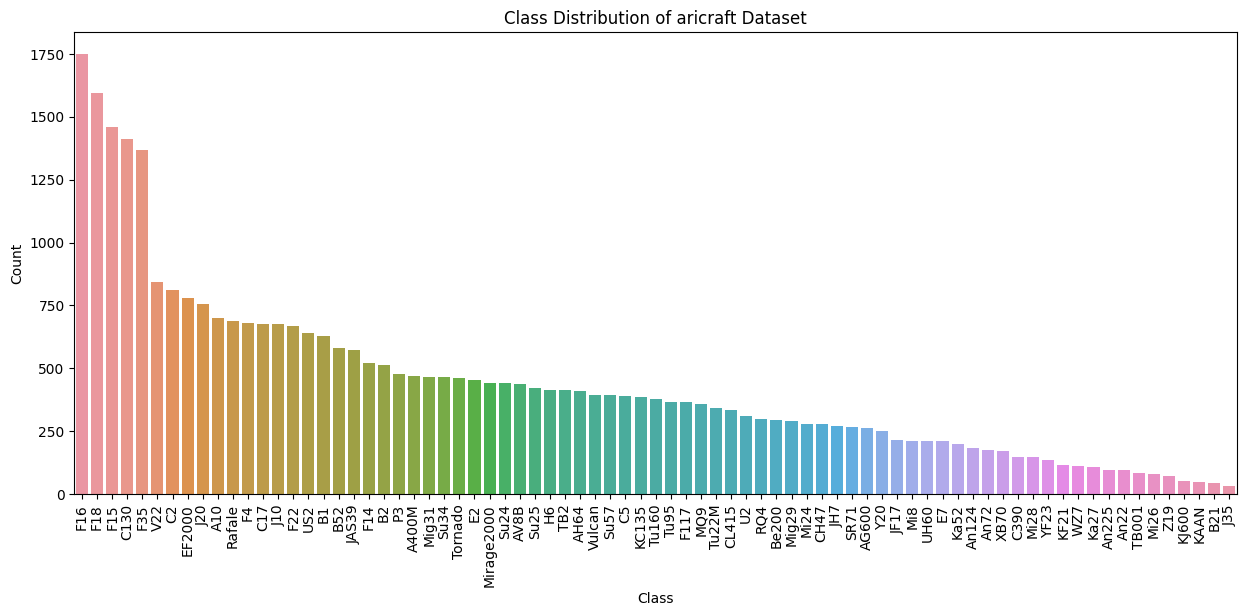

In [7]:


df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
df = df.sort_values("Count", ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x="Class", y="Count", data=df)
plt.xticks(rotation=90)
plt.title("Class Distribution of aricraft Dataset")
plt.show()


### Image Size Analysis

- **Objective:** Calculate the average width and height of the first image from each class.
- **Method:** 
  - Load the first image from each class.
  - Extract dimensions and compute the average.
- **Output:** Displays the average width and height of the images in the dataset.


In [8]:


image_sizes = []
for cls in classes:
    img_path = os.path.join(data_dir, cls, os.listdir(os.path.join(data_dir, cls))[0])  # First image in each class
    with PIL.Image.open(img_path) as img:
        image_sizes.append(img.size)

widths, heights = zip(*image_sizes)

print(f"Average Width: {sum(widths)/len(widths)}, Average Height: {sum(heights)/len(heights)}")


Average Width: 728.1948051948052, Average Height: 297.45454545454544


### Image Size Distribution Visualization

- **Objective:** Visualize the distribution of image widths and heights in the dataset.
- **Method:** 
  - Used seaborn's `histplot` to create histograms for both widths and heights.
  - Added Kernel Density Estimation (KDE) for smoother distribution curves.
- **Output:** 
  - A combined histogram displaying the spread of image dimensions:
    - **Blue** represents width distribution.
    - **Red** represents height distribution.


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


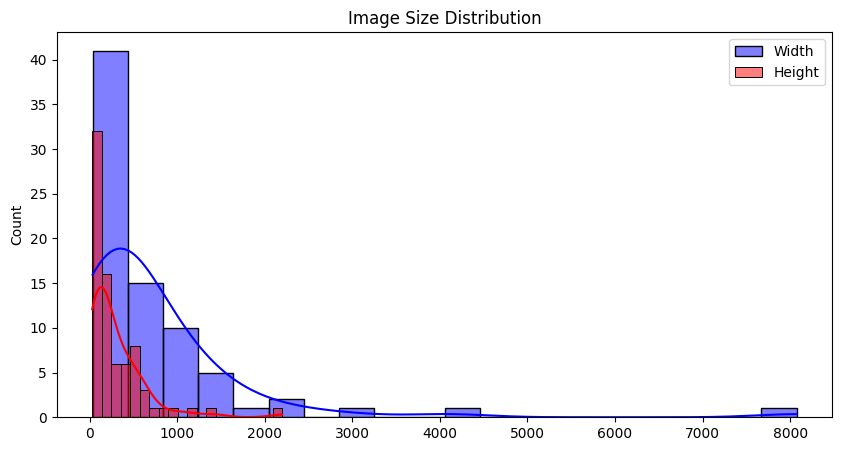

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(widths, bins=20, kde=True, label="Width", color="blue")
sns.histplot(heights, bins=20, kde=True, label="Height", color="red")
plt.legend()
plt.title("Image Size Distribution")
plt.show()


### Sample Images from Random Classes



In [2]:


sample_classes = random.sample(classes, 5)  

plt.figure(figsize=(10, 5))
for i, cls in enumerate(sample_classes):
    img_path = os.path.join(data_dir, cls, os.listdir(os.path.join(data_dir, cls))[0])
    img = PIL.Image.open(img_path)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()


NameError: name 'random' is not defined

### Corrupted Image Detection


- **Method:**
  - Iterated through each class folder and checked every image file.
  - Attempted to open and verify each image using `PIL.Image.open()` and `img.verify()`.
  - If an error occurred while verifying an image, it was added to the `corrupted_files` list.


In [ ]:
corrupted_files = []

for cls in classes:
    folder_path = os.path.join(data_dir, cls)
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted_files.append(img_path)

print(f"Total corrupted images: {len(corrupted_files)}")


### Duplicate Image Detection

- **Method:**
  - For each image in every class folder, the MD5 hash is computed using the `hashlib.md5()` function.
  - If an image with the same hash has already been encountered, it is considered a duplicate and added to the `duplicates` list.


In [ ]:
import hashlib

def get_hash(img_path):
    with open(img_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for cls in classes:
    folder_path = os.path.join(data_dir, cls)
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        img_hash = get_hash(img_path)
        
        if img_hash in hashes:
            duplicates.append(img_path)
        else:
            hashes[img_hash] = img_path

print(f"Duplicate images found: {len(duplicates)}")


# Data Augmentation in Deep Learning

## Why Use Data Augmentation?

Data augmentation helps improve the performance of machine learning models by artificially increasing the size of the training dataset. This is particularly useful when the dataset is small or lacks diversity, as it simulates different scenarios the model might encounter. Here are some key benefits:

- **Reduces Overfitting**: By generating variations of images, the model becomes less likely to memorize the training data, leading to better generalization.
- **Increases Dataset Size**: Augmentation helps in scenarios where obtaining more data is costly or time-consuming.
- **Enhances Robustness**: Models learn to recognize features from various angles, scales, lighting conditions, etc., making them more robust in real-world applications.

## Common Data Augmentation Techniques

### 1. Random Flip
- **Horizontal/Vertical Flip**: Randomly flips the image along the x or y-axis.
- Useful for models that need to recognize objects from different orientations.

### 2. Random Rotation
- Rotates the image by a random angle, ensuring that the model doesn't depend on the exact orientation of objects.
- Helps with rotational invariance.

### 3. Random Zoom
- Zooms in or out on an image by a random factor, helping the model focus on different parts of an object.
- Improves invariance to scale.

### 4. Random Shift
- Randomly shifts the image along the x or y-axis, simulating different positions of objects within the frame.

### 5. Random Crop
- Randomly crops the image to a specific size.
- This can help in simulating various object sizes and cropping due to occlusions or framing issues.

### 6. Random Brightness
- Adjusts the brightness of the image by a random factor.
- Simulates varying lighting conditions and ensures the model doesn’t rely solely on brightness to classify objects.

### 7. Random Contrast
- Adjusts the contrast of the image randomly.
- Helps the model learn to identify objects under different lighting and contrast settings.

### 8. Color Jitter
- Randomly changes the hue, saturation, or brightness of the image.
- Helps improve the model’s ability to generalize across different color variations.

### 9. Gaussian Noise
- Adds random noise to the image.
- Makes the model more robust to noisy or imperfect inputs.

### 10. Shear Transformation
- Shears the image along one axis (like stretching it).
- Useful for simulating different perspectives or angles of view.



In [3]:
data_augmentation = Sequential([
    layers.RandomRotation(0.2),
    layers.RandomWidth(0.2),
    layers.RandomHeight(0.2),
    layers.RandomZoom(0.2),
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),
])


# Building the CNN Model
 -Dataset size is too large so i am traning the model on 11 folder at once 

In [4]:
folder_batch_size = 11
num_class = 77
from sklearn.model_selection import train_test_split

def custom_data_generator(aircraft_image_dict, aircraft_label_dict, selected_classes):
    """
    Loads images from selected classes and yields batches.
    """
    x = []
    y = []
    
    for aircraft_name in selected_classes:
        images = aircraft_image_dict[aircraft_name]
        for image in images:
            img = cv2.imread(str(image))
            if img is not None:
                resized_img = cv2.resize(img, (224, 224))
                x.append(resized_img)
                y.append(aircraft_label_dict[aircraft_name])
    
    # Normalize images and convert labels to one-hot encoding
    x = np.array(x) / 255.0
    y = to_categorical(np.array(y), num_classes=num_class)
    
    yield x, y


# Extract all class names (keys) from the image dictionary
aircraft_classes = list(aircraft_image_dict.keys())

# Training in batches of 11 classes
for i in range(0, len(aircraft_classes), folder_batch_size):
    selected_classes = aircraft_classes[i:i+folder_batch_size]
    print(f"Training on classes: {selected_classes}")
    
    
    train_generator = custom_data_generator(aircraft_image_dict, aircraft_label_dict, selected_classes)
    
    
    # cnn = Sequential([
    #     data_argument,
    #     layers.Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)),
    #     layers.MaxPooling2D(),
    #     layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    #     layers.MaxPooling2D(),
    #     layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    #     layers.MaxPooling2D(),
    #     layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    #     layers.MaxPooling2D(),
    #     layers.Flatten(),
    #     layers.Dense(120, activation='relu'),
    #     layers.Dense(num_class, activation='softmax')  
    # ])
    

    cnn = Sequential([
        data_augmentation,
        layers.Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        
        layers.Flatten(),
        
        layers.Dense(120, activation='relu'),
        layers.Dropout(0.15),   # Dropout before the final dense layer
        
        layers.Dense(num_class, activation='relu')  
    ])


   
    cnn.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    
    x_batch, y_batch = next(train_generator) 
    x_train,x_test,y_train,y_test = train_test_split(x_batch,y_batch,random_state=0)
    cnn.fit(x_train, y_train, epochs=10)
    cnn.evaluate(x_test,y_test)
    
    cnn.save(f'model_batch_{i//folder_batch_size + 1}.h5')
    # K.clear_session()

Training on classes: ['CL415', 'JAS39', 'C5', 'E2', 'Mig31', 'KAAN', 'RQ4', 'Mirage2000', 'B2', 'US2', 'H6']


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Sequential model 'sequential' has no defined input shape yet.

In [ ]:
tr_acc = cnn['accuracy']
tr_loss = cnn.history['loss']
val_acc = cnn.history['val_accuracy']
val_loss = cnn.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

Epochs = [i+1 for i in range(len(tr_acc))]

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'orange', label= 'Training loss')
plt.plot(Epochs, val_loss, label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'red', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'orange', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'red', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [ ]:
pred = cnn.predict(x_test)
score = tf.nn.softmax(pred[0])
np.argmax(score)